# 🎙️ Telugu ASR Pipeline — File 1 of 3
## Data Exploration, Cleaning & Preprocessing

---

### 🎯 Objective
This notebook is the **first stage** of a 3-file end-to-end Automatic Speech Recognition (ASR) pipeline for **Telugu** — a morphologically complex, low-resource Dravidian language. It handles everything from raw dataset download to a clean, normalized, HuggingFace-compatible dataset ready for fine-tuning.

---

### 📋 Dataset Metadata

| Property | Value |
|---|---|
| **Dataset Name** | Microsoft Speech Corpus for Indian Languages — Telugu Subset |
| **Kaggle Slug** | `srikarcod3r/telugu-mscil` |
| **Audio Format** | WAV, 16 kHz, Mono |
| **Training Samples** | ~44,000+ |
| **Test Samples** | ~3,000 |
| **Language** | Telugu (ISO 639-2: `tel`) |
| **Script** | Telugu Unicode Block U+0C00–U+0C7F |
| **Task** | Automatic Speech Recognition (ASR) |

---

### 📂 Downstream File References

| File | Purpose |
|---|---|
| `01_data_exploration_and_cleaning.ipynb` | **This file** — data pipeline, EDA, normalization, save |
| `02_model_finetuning.ipynb` | Whisper fine-tuning on the clean dataset |
| `03_evaluation_and_inference.ipynb` | WER/CER evaluation + inference demos |

---

### 🗺️ Notebook Flow
```
Download → Explore → Load Metadata → Resolve Audio Paths
   → HuggingFace Dataset → EDA → Duration Filter
   → Text Normalization → Character Inventory → Save
```

## 📦 Section 1 — Environment Setup

**Rationale:** Install and import all required libraries before doing any work. Printing library versions ensures reproducibility across different environments and makes debugging version-related issues straightforward.

In [1]:
# ═══════════════════════════════════════════════════════════════
# SECTION 1 — ENVIRONMENT SETUP: Install Dependencies
# ═══════════════════════════════════════════════════════════════

# Install kagglehub for authenticated Kaggle dataset downloads
# Install datasets (HuggingFace) for Dataset objects and Audio casting
# Install librosa for audio duration extraction and processing
# Install soundfile as the backend audio I/O library used by librosa
# Install matplotlib for all plotting and figure generation
# Install seaborn for enhanced statistical plot aesthetics
# Install tqdm for progress bars on long-running loops
# Install pandas for DataFrame operations on metadata
# The -q flag suppresses verbose pip output to keep the notebook tidy
import subprocess  # Used to run pip install as a subprocess
subprocess.run(
    ["pip", "install", "-q",
     "kagglehub",       # Kaggle dataset downloader
     "datasets",        # HuggingFace Datasets library
     "librosa",         # Audio analysis (duration, spectrograms)
     "soundfile",       # Low-level audio file I/O backend
     "matplotlib",      # Core plotting library
     "seaborn",         # Statistical visualization on top of matplotlib
     "tqdm",            # Progress bars for loops
     "pandas",          # Tabular data manipulation
    ],
    check=True  # Raise an exception if pip fails, surfacing errors early
)
print("✅ All dependencies installed successfully.")  # Confirm installation completed

✅ All dependencies installed successfully.


In [2]:
# ───────────────────────────────────────────────────────────────
# SECTION 1 — ENVIRONMENT SETUP: Imports
# ───────────────────────────────────────────────────────────────

import os                       # File system navigation (walk, path operations)
import re                       # Regular expressions for text normalization
import json                     # Read/write character inventory JSON file
import collections              # Counter for character frequency analysis
import warnings                 # Suppress non-critical runtime warnings

import numpy as np              # Numerical array operations (stats on durations)
import pandas as pd             # DataFrame for metadata manipulation
import matplotlib               # Core plotting engine (version access)
import matplotlib.pyplot as plt # pyplot interface for creating figures
import seaborn as sns           # Statistical plots with cleaner defaults
import librosa                  # Audio analysis: duration extraction
import soundfile as sf          # Low-level WAV file reading (librosa backend)
from tqdm import tqdm           # Progress bars for per-sample operations

import kagglehub                # Kaggle dataset authenticated download utility
from datasets import Dataset, Audio, load_from_disk  # HuggingFace Dataset API
# Suppress librosa/audioread UserWarnings to keep output readable
warnings.filterwarnings("ignore", category=UserWarning)

print("✅ All libraries imported successfully.")  # Confirm imports did not raise

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully.


In [3]:
# ───────────────────────────────────────────────────────────────
# SECTION 1 — ENVIRONMENT SETUP: Global Plot Aesthetics & Versions
# ───────────────────────────────────────────────────────────────

# Set seaborn white-grid style for clean, readable plots throughout the notebook
sns.set_style("whitegrid")

# Configure global matplotlib defaults so all figures look consistent
plt.rcParams["figure.figsize"] = (14, 6)   # Default figure size: 14 inches wide, 6 tall
plt.rcParams["figure.dpi"] = 100            # Screen DPI for crisp inline rendering
plt.rcParams["font.size"] = 12              # Base font size for labels, ticks, titles
plt.rcParams["axes.titlesize"] = 14         # Slightly larger title font for each subplot
plt.rcParams["axes.labelsize"] = 12         # Axis label font size

# Print library versions to ensure reproducibility when comparing runs
print("📋 Library Versions for Reproducibility:")
print(f"   numpy      : {np.__version__}")          # NumPy version
print(f"   pandas     : {pd.__version__}")          # Pandas version
print(f"   matplotlib : {matplotlib.__version__}")  # Matplotlib version
print(f"   seaborn    : {sns.__version__}")         # Seaborn version
print(f"   librosa    : {librosa.__version__}")     # Librosa version
print(f"   soundfile  : {sf.__version__}")          # SoundFile version

# Import datasets version separately since it lives in a sub-module
import datasets as _datasets_module  # Import as alias to access __version__
print(f"   datasets   : {_datasets_module.__version__}")  # HuggingFace Datasets version
print(f"   kagglehub  : {kagglehub.__version__}")  # KaggleHub version
print("✅ Environment configuration complete.")

📋 Library Versions for Reproducibility:
   numpy      : 2.2.6
   pandas     : 2.3.3
   matplotlib : 3.10.8
   seaborn    : 0.13.2
   librosa    : 0.11.0
   soundfile  : 0.13.1
   datasets   : 2.21.0
   kagglehub  : 1.0.0
✅ Environment configuration complete.


## 📥 Section 2 — Dataset Download

**Rationale:** Using `kagglehub` ensures authenticated, cached downloads directly from Kaggle. We verify the path exists, then walk the directory tree to understand the raw dataset structure before touching any files.

In [4]:
# ═══════════════════════════════════════════════════════════════
# SECTION 2 — DATASET DOWNLOAD
# ═══════════════════════════════════════════════════════════════

print("📥 Downloading Telugu MSCIL dataset from Kaggle...")

# Download (or retrieve from local cache) the Kaggle dataset by its slug
# kagglehub caches downloads, so re-running is fast if already downloaded
dataset_root_path: str = kagglehub.dataset_download("srikarcod3r/telugu-mscil")

# Assert that the returned path actually exists on disk before proceeding
assert os.path.exists(dataset_root_path), f"❌ Dataset path does not exist: {dataset_root_path}"

print(f"✅ Dataset downloaded/cached at: {dataset_root_path}")  # Show the local cache path

📥 Downloading Telugu MSCIL dataset from Kaggle...
✅ Dataset downloaded/cached at: /home/jovyan/.cache/kagglehub/datasets/srikarcod3r/telugu-mscil/versions/1


In [5]:
# ───────────────────────────────────────────────────────────────
# SECTION 2 — DATASET DOWNLOAD: Directory Tree Walk
# ───────────────────────────────────────────────────────────────

MAX_FILES_PER_DIR: int = 10         # Maximum number of files to display per directory
all_extensions: set = set()         # Accumulate all unique file extensions seen

print("\n📁 Dataset Directory Tree:")  # Header for the tree output
print("═" * 60)  # Visual separator

# Walk the entire dataset directory tree: root, subdirectory names, file names
for walk_root, walk_dirs, walk_files in os.walk(dataset_root_path):

    # Compute indentation depth by counting path separators relative to dataset root
    indent_depth: int = walk_root.replace(dataset_root_path, "").count(os.sep)
    indent_prefix: str = "  " * indent_depth  # Two spaces per level of depth

    # Print the current directory name with a folder emoji
    dir_display_name: str = os.path.basename(walk_root) or walk_root
    print(f"{indent_prefix}📁 {dir_display_name}/")  # Show directory label

    # Collect unique extensions from every file in this directory
    for fname in walk_files:
        file_ext: str = os.path.splitext(fname)[1].lower()  # Extract lowercase extension
        all_extensions.add(file_ext)  # Add to global extension set

    # Determine how many files to show: cap at MAX_FILES_PER_DIR
    files_to_show: list = walk_files[:MAX_FILES_PER_DIR]
    overflow_count: int = max(0, len(walk_files) - MAX_FILES_PER_DIR)  # Files beyond the cap

    file_indent_prefix: str = "  " * (indent_depth + 1)  # One extra level for file lines

    for fname in files_to_show:
        full_file_path: str = os.path.join(walk_root, fname)  # Build absolute path to file
        file_size_kb: float = os.path.getsize(full_file_path) / 1024  # File size in kilobytes
        print(f"{file_indent_prefix}📄 {fname}  ({file_size_kb:.1f} KB)")  # Print name and size

    if overflow_count > 0:  # Only print overflow line if there are hidden files
        print(f"{file_indent_prefix}... and {overflow_count} more files")  # Show overflow count

print("═" * 60)  # Visual separator after tree
print(f"\n📊 Unique file extensions found: {sorted(all_extensions)}")  # Summary of extensions
print("✅ Directory tree walk complete.")  # Confirm walk finished


📁 Dataset Directory Tree:
════════════════════════════════════════════════════════════
📁 1/
  📁 telugu_microsoft_corpus/
    📁 microsoftspeechcorpusindianlanguages/
      📁 te-in-Train/
        📄 transcription.txt  (5802.5 KB)
        📄 train_transcriptions.csv  (5934.0 KB)
        📁 Audios/
          📄 TE0733-TE0734_2-B.175.wav  (33.6 KB)
          📄 002030387.wav  (132.2 KB)
          📄 TE0442-TE0444_1-A.132.wav  (136.6 KB)
          📄 TE0451-TE0452_1-A.081.wav  (44.9 KB)
          📄 TE0606-TE0608_1-B.570.wav  (30.5 KB)
          📄 TE0470-TE0472_2-B.286.wav  (51.6 KB)
          📄 TE0726-TE0728_1-B.301.wav  (55.1 KB)
          📄 002040175.wav  (186.3 KB)
          📄 002280026.wav  (160.7 KB)
          📄 001010203.wav  (164.7 KB)
          ... and 44872 more files
      📁 te-in-Test/
        📄 test_transcriptions.csv  (667.1 KB)
        📄 test_transcriptions.txt  (658.2 KB)
        📁 Audios/
          📄 000540009.wav  (213.8 KB)
          📄 000430197.wav  (104.1 KB)
          📄 000160

## 🔍 Section 3 — Metadata Discovery & Loading

**Rationale:** We cannot assume a fixed file layout — datasets sometimes ship with different naming conventions. Auto-discovery makes this notebook robust to layout variations. We inspect raw lines before parsing to avoid hard-coding a delimiter that might differ from the actual file.

In [6]:
# ═══════════════════════════════════════════════════════════════
# SECTION 3 — METADATA DISCOVERY & LOADING: File Discovery
# ═══════════════════════════════════════════════════════════════

text_file_candidates: list = []   # Will hold (path, size_bytes) for all text/csv/tsv files
wav_directories: dict = {}        # Will map directory path → WAV file count

# Recursively walk the dataset to find transcription files and WAV directories
for walk_root, walk_dirs, walk_files in os.walk(dataset_root_path):
    wav_count_in_dir: int = 0  # Reset WAV counter for each directory

    for fname in walk_files:
        full_path: str = os.path.join(walk_root, fname)  # Full absolute path to this file
        file_ext: str = os.path.splitext(fname)[1].lower()  # Lowercase extension

        # Check if this file is a potential transcription mapping (text, CSV, or TSV)
        if file_ext in (".txt", ".tsv", ".csv"):
            size_bytes: int = os.path.getsize(full_path)  # Size for selecting the largest
            text_file_candidates.append((full_path, size_bytes))  # Add to candidates list

        # Count WAV files separately to locate the audio directories
        if file_ext == ".wav":
            wav_count_in_dir += 1  # Increment WAV counter for this directory

    if wav_count_in_dir > 0:  # Only record directories that actually contain WAV files
        wav_directories[walk_root] = wav_count_in_dir  # Store directory and its WAV count

# ── Report text file discoveries ──
print("📋 Transcription File Candidates Found:")
for candidate_path, candidate_size in sorted(text_file_candidates, key=lambda x: x[1], reverse=True):
    print(f"   {candidate_path}  ({candidate_size / 1024:.1f} KB)")  # Show path and KB size

# ── Report WAV directory discoveries ──
print("\n🎵 Directories Containing WAV Files:")
for wav_dir, wav_count in sorted(wav_directories.items(), key=lambda x: x[1], reverse=True):
    print(f"   {wav_dir}  ({wav_count} WAV files)")  # Show directory and file count

print(f"\n📊 Total text candidates: {len(text_file_candidates)}")  # Summary count
print(f"📊 Total WAV directories : {len(wav_directories)}")        # Summary count
print("✅ Discovery complete.")  # Confirm discovery finished

📋 Transcription File Candidates Found:
   /home/jovyan/.cache/kagglehub/datasets/srikarcod3r/telugu-mscil/versions/1/telugu_microsoft_corpus/microsoftspeechcorpusindianlanguages/te-in-Train/train_transcriptions.csv  (5934.0 KB)
   /home/jovyan/.cache/kagglehub/datasets/srikarcod3r/telugu-mscil/versions/1/telugu_microsoft_corpus/microsoftspeechcorpusindianlanguages/te-in-Train/transcription.txt  (5802.5 KB)
   /home/jovyan/.cache/kagglehub/datasets/srikarcod3r/telugu-mscil/versions/1/telugu_microsoft_corpus/microsoftspeechcorpusindianlanguages/te-in-Test/test_transcriptions.csv  (667.1 KB)
   /home/jovyan/.cache/kagglehub/datasets/srikarcod3r/telugu-mscil/versions/1/telugu_microsoft_corpus/microsoftspeechcorpusindianlanguages/te-in-Test/test_transcriptions.txt  (658.2 KB)
   /home/jovyan/.cache/kagglehub/datasets/srikarcod3r/telugu-mscil/versions/1/telugu_microsoft_corpus/microsoftspeechcorpusindianlanguages/te-in-Measurement/validation_transcriptions.csv  (84.4 KB)
   /home/jovyan/.cac

In [7]:
# ───────────────────────────────────────────────────────────────
# SECTION 3 — METADATA DISCOVERY & LOADING: Load Transcription File
# ───────────────────────────────────────────────────────────────

# Select the largest text file as the primary transcription source
# Sorting descending by size and taking the first ensures we get the main mapping file
primary_text_file: str = sorted(text_file_candidates, key=lambda x: x[1], reverse=True)[0][0]
print(f"📋 Primary transcription file selected: {primary_text_file}")  # Show selected path

# Preview the first 5 raw lines using repr() to expose whitespace/delimiter characters
print("\n🔎 First 5 raw lines (repr) for delimiter inspection:")
with open(primary_text_file, "r", encoding="utf-8") as raw_file_handle:  # Open in text mode
    for line_index, raw_line in enumerate(raw_file_handle):  # Iterate line by line
        if line_index >= 5:  # Stop after 5 lines to keep output concise
            break
        print(f"   Line {line_index}: {repr(raw_line)}")  # Print repr to show \t, \n, spaces

# ── Auto-detect delimiter by checking the first non-empty line ──
detected_delimiter: str = r"\s+"  # Default fallback: split on any whitespace
with open(primary_text_file, "r", encoding="utf-8") as probe_handle:  # Open for probing
    for probe_line in probe_handle:  # Scan lines until we find a non-empty one
        stripped_probe: str = probe_line.strip()  # Remove leading/trailing whitespace
        if not stripped_probe:  # Skip blank lines
            continue
        if "\t" in stripped_probe:   # Tab is the most common TSV delimiter — check first
            detected_delimiter = "\t"  # Use literal tab as delimiter
        elif "," in stripped_probe:  # Comma is the next most likely CSV delimiter
            detected_delimiter = ","  # Use literal comma as delimiter
        # If neither, keep the whitespace regex fallback
        break  # Only need the first non-empty line to determine the delimiter

print(f"\n🔎 Auto-detected delimiter: {repr(detected_delimiter)}")  # Show detected delimiter

# ── Load the full transcription file into a DataFrame ──
# header=None: the file has no header row
# engine='python': supports regex separators (needed for whitespace fallback)
# on_bad_lines='skip': skip malformed lines rather than crashing
# encoding='utf-8': Telugu Unicode text requires UTF-8
raw_metadata_df: pd.DataFrame = pd.read_csv(
    primary_text_file,          # Path to the transcription mapping file
    sep=detected_delimiter,     # Use auto-detected delimiter
    header=None,                # No column headers in the raw file
    engine="python",            # Python engine required for regex separator
    on_bad_lines="skip",        # Silently skip rows that cannot be parsed
    encoding="utf-8",           # Ensure Telugu characters are read correctly
)
print(f"\n📊 Raw DataFrame shape: {raw_metadata_df.shape}")  # Show rows x columns
print(f"📊 Columns found: {list(raw_metadata_df.columns)}")  # Show column indices
print(raw_metadata_df.head(3))  # Preview first 3 rows for sanity check
print("✅ Raw metadata loaded.")  # Confirm load success

📋 Primary transcription file selected: /home/jovyan/.cache/kagglehub/datasets/srikarcod3r/telugu-mscil/versions/1/telugu_microsoft_corpus/microsoftspeechcorpusindianlanguages/te-in-Train/train_transcriptions.csv

🔎 First 5 raw lines (repr) for delimiter inspection:
   Line 0: '\ufeffaudio_path_file,transcription\n'
   Line 1: 'TE2406-TE2408_1-A.089.wav,కచ్చితంగా చూపిస్తుంది కదా మరి\n'
   Line 2: 'TE0513-TE0515_2-B.069.wav,అ చరణ్ కదా తెలుసు\n'
   Line 3: 'TE0797-TE0799_1-A.233.wav,చప్పాలంటే చాలా ఉంటాయి గాని\n'
   Line 4: 'TE0771-TE0772_1-A.214.wav,మనకు ఇంకా అన్నయ్యలకు కూడా చాలా మంచిదంటండి\n'

🔎 Auto-detected delimiter: ','

📊 Raw DataFrame shape: (44883, 2)
📊 Columns found: [0, 1]
                           0                              1
0            audio_path_file                  transcription
1  TE2406-TE2408_1-A.089.wav  కచ్చితంగా చూపిస్తుంది కదా మరి
2  TE0513-TE0515_2-B.069.wav              అ చరణ్ కదా తెలుసు
✅ Raw metadata loaded.


In [8]:
# ───────────────────────────────────────────────────────────────
# SECTION 3 — METADATA DISCOVERY & LOADING: Standardize Columns
# ───────────────────────────────────────────────────────────────

num_raw_columns: int = len(raw_metadata_df.columns)  # Total number of columns parsed
print(f"📊 Number of columns in raw DataFrame: {num_raw_columns}")  # Diagnostic info

if num_raw_columns > 2:
    # If more than 2 columns were parsed, the transcription itself may contain delimiters
    # Treat column 0 as audio_id and concatenate all remaining columns into transcription
    audio_id_series: pd.Series = raw_metadata_df.iloc[:, 0]  # First column is always audio_id
    # Join all columns from index 1 onward with a space to reconstruct the full transcription
    transcription_series: pd.Series = raw_metadata_df.iloc[:, 1:].apply(
        lambda row_values: " ".join(row_values.dropna().astype(str)),  # Concat non-null cols
        axis=1  # Apply row-wise
    )
    print(f"⚠️  {num_raw_columns} columns detected — concatenating columns 1..{num_raw_columns-1} into transcription.")

elif num_raw_columns == 2:
    # Exactly 2 columns — straightforward: first is audio_id, second is transcription
    audio_id_series: pd.Series = raw_metadata_df.iloc[:, 0]  # Column 0 = audio file id
    transcription_series: pd.Series = raw_metadata_df.iloc[:, 1]  # Column 1 = text
    print("✅ 2 columns detected — standard audio_id/transcription mapping.")  # Normal case

else:
    # Only 1 column — file was not split; split on first whitespace token
    # This handles space-separated files loaded with a non-matching delimiter
    split_result: pd.DataFrame = raw_metadata_df.iloc[:, 0].str.split(n=1, expand=True)  # Split on first space
    audio_id_series: pd.Series = split_result[0]          # Part before first space = audio_id
    transcription_series: pd.Series = split_result[1]     # Everything after = transcription
    print("⚠️  1 column detected — splitting on first whitespace.")  # Inform about fallback

# ── Build standardized DataFrame with exactly 2 named columns ──
metadata_df: pd.DataFrame = pd.DataFrame({
    "audio_id": audio_id_series.values,         # Audio file identifier (stem or filename)
    "transcription": transcription_series.values  # Telugu transcription text
})

# Strip leading/trailing whitespace from both columns to remove stray spaces/newlines
metadata_df["audio_id"] = metadata_df["audio_id"].str.strip()           # Clean audio_id
metadata_df["transcription"] = metadata_df["transcription"].str.strip() # Clean transcription

# Record row count before dropping missing data for the audit trail
rows_before_drop: int = len(metadata_df)  # Snapshot count before any drops

# Drop rows where transcription is NaN (missing) or an empty string after stripping
metadata_df.dropna(subset=["transcription"], inplace=True)  # Remove NaN transcriptions
metadata_df = metadata_df[metadata_df["transcription"] != ""]  # Remove empty string rows

# Count how many rows were removed due to missing/empty transcriptions
rows_dropped_empty: int = rows_before_drop - len(metadata_df)  # Difference = dropped rows

# Reset DataFrame index after filtering so indices are contiguous 0..N
metadata_df.reset_index(drop=True, inplace=True)  # Drop old index, create fresh sequential index

print(f"\n📊 Standardized DataFrame shape  : {metadata_df.shape}")     # Final shape
print(f"📊 Rows dropped (empty/NaN text) : {rows_dropped_empty}")      # Transparency audit
print(metadata_df.head(5).to_string())  # Show first 5 rows for manual spot-check
print("\n✅ Metadata standardized and cleaned.")  # Confirm section success

📊 Number of columns in raw DataFrame: 2
✅ 2 columns detected — standard audio_id/transcription mapping.

📊 Standardized DataFrame shape  : (44883, 2)
📊 Rows dropped (empty/NaN text) : 0
                    audio_id                              transcription
0            audio_path_file                              transcription
1  TE2406-TE2408_1-A.089.wav              కచ్చితంగా చూపిస్తుంది కదా మరి
2  TE0513-TE0515_2-B.069.wav                          అ చరణ్ కదా తెలుసు
3  TE0797-TE0799_1-A.233.wav                 చప్పాలంటే చాలా ఉంటాయి గాని
4  TE0771-TE0772_1-A.214.wav  మనకు ఇంకా అన్నయ్యలకు కూడా చాలా మంచిదంటండి

✅ Metadata standardized and cleaned.


## 🔗 Section 4 — Audio Path Resolution

**Rationale:** Transcription files store audio IDs in various formats (stem only, with extension, relative path, etc.). A multi-strategy resolver with an O(1) lookup dictionary handles all common cases without slow directory walks per sample.

In [9]:
# ═══════════════════════════════════════════════════════════════
# SECTION 4 — AUDIO PATH RESOLUTION
# ═══════════════════════════════════════════════════════════════

print("🎵 Collecting all WAV file paths recursively...")  # Progress indicator

all_wav_paths: list = []  # Flat list of all absolute WAV file paths found in the dataset

# Walk the entire dataset directory tree to find every WAV file
for walk_root, _, walk_files in os.walk(dataset_root_path):
    for fname in walk_files:  # Iterate every file in this directory
        if fname.lower().endswith(".wav"):  # Only collect audio files
            full_wav_path: str = os.path.join(walk_root, fname)  # Build full absolute path
            all_wav_paths.append(full_wav_path)  # Add to the master list

print(f"✅ Total WAV files found: {len(all_wav_paths)}")  # Report how many WAVs exist

# ── Build O(1) lookup dictionary with multiple key strategies ──
# Strategy 1: exact filename (e.g. "file_001.wav") → path
# Strategy 2: filename stem without extension (e.g. "file_001") → path
audio_path_lookup: dict = {}  # Master lookup: string key → absolute path

for wav_path in all_wav_paths:
    wav_filename: str = os.path.basename(wav_path)              # E.g. "file_001.wav"
    wav_stem: str = os.path.splitext(wav_filename)[0]           # E.g. "file_001" (no extension)
    audio_path_lookup[wav_filename] = wav_path  # Key: full filename with extension
    audio_path_lookup[wav_stem] = wav_path      # Key: stem without extension

print(f"📊 Lookup dictionary entries: {len(audio_path_lookup)}")  # Show map size

# ── Define the resolution function with three fallback strategies ──
def resolve_audio_path(audio_id: str) -> str:
    """Attempt to resolve an audio_id string to an absolute WAV file path.

    Strategy 1 — Exact match: look up audio_id directly (works for full filenames).
    Strategy 2 — Stem match: strip any extension from audio_id, then look up.
    Strategy 3 — Stem + '.wav': append '.wav' to the stem, then look up.

    Returns the resolved absolute path or None if all strategies fail.
    """
    # Strategy 1: direct lookup — handles both stem-only and full-filename IDs
    if audio_id in audio_path_lookup:
        return audio_path_lookup[audio_id]  # Return immediately on exact match

    # Strategy 2: strip any extension the audio_id may carry, then look up the stem
    audio_id_stem: str = os.path.splitext(audio_id)[0]  # Remove extension if present
    if audio_id_stem in audio_path_lookup:
        return audio_path_lookup[audio_id_stem]  # Return stem match

    # Strategy 3: append '.wav' to the stem and try one more lookup
    stem_with_wav: str = audio_id_stem + ".wav"  # Construct "stem.wav" key
    if stem_with_wav in audio_path_lookup:
        return audio_path_lookup[stem_with_wav]  # Return stem+extension match

    return None  # All three strategies exhausted — this ID cannot be resolved

# ── Apply the resolver to every audio_id in the metadata DataFrame ──
print("\n🔗 Resolving audio paths for all metadata entries...")  # Progress message
metadata_df["audio_path"] = metadata_df["audio_id"].apply(resolve_audio_path)  # Apply resolver

# Count how many entries were successfully matched to a file path
total_entries: int = len(metadata_df)                                         # Total rows
matched_entries: int = metadata_df["audio_path"].notna().sum()               # Non-None paths
unmatched_entries: int = total_entries - matched_entries                      # Failed resolutions
match_rate_pct: float = (matched_entries / total_entries) * 100               # Match percentage

print(f"\n📊 Audio Path Resolution Report:")
print(f"   Total entries  : {total_entries}")               # All rows in metadata
print(f"   Matched        : {matched_entries}  ({match_rate_pct:.2f}%)")  # Successful matches
print(f"   Unmatched      : {unmatched_entries}")           # Failed matches

if unmatched_entries > 0:  # Only show examples if there are failures
    # Show up to 10 unmatched audio_ids so the user can investigate
    unmatched_sample_ids: list = metadata_df[metadata_df["audio_path"].isna()]["audio_id"].head(10).tolist()
    print(f"⚠️  Sample unmatched audio_ids: {unmatched_sample_ids}")  # Show sample failures

# ── Drop unmatched rows to create the final clean path-resolved DataFrame ──
resolved_metadata_df: pd.DataFrame = metadata_df.dropna(subset=["audio_path"]).copy()  # Keep only resolved rows
resolved_metadata_df.reset_index(drop=True, inplace=True)  # Reset index after filtering

print(f"\n✅ Final resolved DataFrame: {len(resolved_metadata_df)} rows")  # Confirm final count

🎵 Collecting all WAV file paths recursively...
✅ Total WAV files found: 50471
📊 Lookup dictionary entries: 100940

🔗 Resolving audio paths for all metadata entries...

📊 Audio Path Resolution Report:
   Total entries  : 44883
   Matched        : 44882  (100.00%)
   Unmatched      : 1
⚠️  Sample unmatched audio_ids: ['audio_path_file']

✅ Final resolved DataFrame: 44882 rows


## 🤗 Section 5 — Build HuggingFace Dataset

**Rationale:** HuggingFace `datasets.Dataset` provides automatic WAV loading, resampling, batched processing, and disk serialization — all critical for efficient fine-tuning in File 2. Casting the `audio` column to `Audio(sampling_rate=16000)` ensures every file is resampled on-the-fly to 16 kHz (Whisper's expected input).

In [10]:
# ═══════════════════════════════════════════════════════════════
# SECTION 5 — BUILD HUGGINGFACE DATASET
# ═══════════════════════════════════════════════════════════════


print("🤗 Building HuggingFace Dataset object...")  # Progress message

# Construct the HuggingFace Dataset from a Python dictionary of lists
# 'audio'         : list of absolute WAV file paths — will be cast to Audio feature
# 'transcription' : list of Telugu transcription strings
# 'audio_id'      : list of original audio_id strings for traceability
hf_dataset: Dataset = Dataset.from_dict({
    "audio":         resolved_metadata_df["audio_path"].tolist(),       # Absolute WAV paths
    "transcription": resolved_metadata_df["transcription"].tolist(),    # Telugu text
    "audio_id":      resolved_metadata_df["audio_id"].tolist(),         # Original IDs
})

# Cast the 'audio' string-path column to HuggingFace Audio feature type
# This enables automatic WAV loading + resampling to 16 kHz when samples are accessed
hf_dataset = hf_dataset.cast_column(
    "audio",                        # Column to cast
    Audio(sampling_rate=16000)       # Cast to Audio with 16 kHz target sampling rate
)

# Print dataset metadata summary for verification
print(f"\n📊 HuggingFace Dataset Summary:")
print(f"   Number of samples : {len(hf_dataset)}")   # Total row count
print(f"   Features          : {hf_dataset.features}")  # Column names and types

# Preview 3 sample records to verify audio, transcription, and audio_id are correct
print("\n📋 Sample Records Preview (first 3):")
for sample_index in range(min(3, len(hf_dataset))):  # Iterate first 3 samples safely
    sample_record: dict = hf_dataset[sample_index]  # Fetch one record (triggers WAV decode)
    sample_audio_path: str = sample_record["audio"]["path"]               # File path from Audio
    sample_text: str = sample_record["transcription"]                      # Telugu text
    sample_sr: int = sample_record["audio"]["sampling_rate"]               # Sampling rate (Hz)
    sample_audio_id: str = sample_record["audio_id"]                       # Original ID
    print(f"   [{sample_index}] audio_id  : {sample_audio_id}")            # Show ID
    print(f"       path       : {sample_audio_path}")                      # Show path
    print(f"       text       : {sample_text}")                            # Show Telugu text
    print(f"       sample_rate: {sample_sr} Hz")                           # Show sampling rate
    print()

print("✅ HuggingFace Dataset constructed successfully.")  # Confirm build success

🤗 Building HuggingFace Dataset object...

📊 HuggingFace Dataset Summary:
   Number of samples : 44882
   Features          : {'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'transcription': Value(dtype='string', id=None), 'audio_id': Value(dtype='string', id=None)}

📋 Sample Records Preview (first 3):
   [0] audio_id  : TE2406-TE2408_1-A.089.wav
       path       : /home/jovyan/.cache/kagglehub/datasets/srikarcod3r/telugu-mscil/versions/1/telugu_microsoft_corpus/microsoftspeechcorpusindianlanguages/te-in-Train/Audios/TE2406-TE2408_1-A.089.wav
       text       : కచ్చితంగా చూపిస్తుంది కదా మరి
       sample_rate: 16000 Hz

   [1] audio_id  : TE0513-TE0515_2-B.069.wav
       path       : /home/jovyan/.cache/kagglehub/datasets/srikarcod3r/telugu-mscil/versions/1/telugu_microsoft_corpus/microsoftspeechcorpusindianlanguages/te-in-Train/Audios/TE0513-TE0515_2-B.069.wav
       text       : అ చరణ్ కదా తెలుసు
       sample_rate: 16000 Hz

   [2] audio_id  : TE0797-TE0799_1

## 📊 Section 6 — Exploratory Data Analysis (EDA)

**Rationale:** Understanding the distribution of audio durations and transcription lengths is essential before training. Very short clips (<1s) are often silence or noise. Very long clips (>15s) can cause VRAM OOM during training and degrade Whisper's performance. The scatter plot reveals whether longer text correlates with longer audio (expected) or flags anomalies.

In [11]:
# ═══════════════════════════════════════════════════════════════
# SECTION 6 — EDA: Compute Audio Durations
# ═══════════════════════════════════════════════════════════════

CORRUPT_SENTINEL: float = -1.0  # Sentinel value for files that cannot be read

print("⏱️  Computing audio durations (this may take a few minutes)...")  # Warn about time

# Extract all audio file paths from the HuggingFace dataset efficiently without decoding
# Accessing 'audio' column directly returns the dict with 'path' key without full decode
all_audio_paths_for_eda: list = hf_dataset["audio"]  # List of audio dicts

audio_durations: list = []  # Will hold one duration (seconds) per sample

# Iterate with a progress bar so the user can see progress on ~44k files
for audio_dict in tqdm(all_audio_paths_for_eda, desc="📐 Computing durations", unit="file"):
    audio_file_path: str = audio_dict["path"]  # Extract the absolute path string
    try:
        # Use librosa.get_duration(path=...) which reads only the header — very fast
        clip_duration_seconds: float = librosa.get_duration(path=audio_file_path)  # Duration in seconds
        audio_durations.append(clip_duration_seconds)  # Append successful duration
    except Exception:  # Catch any exception (corrupt file, missing file, codec error)
        audio_durations.append(CORRUPT_SENTINEL)  # Record sentinel so index stays aligned

# Convert to numpy array for efficient vectorized statistics
durations_array: np.ndarray = np.array(audio_durations, dtype=np.float32)  # Float32 is sufficient

# Isolate valid durations (exclude sentinel values) for statistics
valid_durations: np.ndarray = durations_array[durations_array > CORRUPT_SENTINEL]  # Positive durations only
corrupt_file_count: int = int(np.sum(durations_array == CORRUPT_SENTINEL))  # Number of corrupt files

# ── Print comprehensive duration statistics ──
print("\n📊 Audio Duration Statistics:")
print(f"   Total samples       : {len(durations_array)}")                             # All samples
print(f"   Corrupt/unreadable  : {corrupt_file_count}")                               # Bad files
print(f"   Valid samples       : {len(valid_durations)}")                             # Good files
print(f"   Min duration        : {valid_durations.min():.3f} s")                      # Shortest clip
print(f"   Max duration        : {valid_durations.max():.3f} s")                      # Longest clip
print(f"   Mean duration       : {valid_durations.mean():.3f} s")                     # Average
print(f"   Median duration     : {np.median(valid_durations):.3f} s")                 # Median
print(f"   Std deviation       : {valid_durations.std():.3f} s")                      # Spread
print(f"   Total audio (hours) : {valid_durations.sum() / 3600:.2f} h")              # Dataset hours
print("\n✅ Duration computation complete.")  # Confirm step done

⏱️  Computing audio durations (this may take a few minutes)...


📐 Computing durations: 100%|██████████| 44882/44882 [00:04<00:00, 9011.32file/s]


📊 Audio Duration Statistics:
   Total samples       : 44882
   Corrupt/unreadable  : 0
   Valid samples       : 44882
   Min duration        : 0.325 s
   Max duration        : 23.610 s
   Mean duration       : 3.208 s
   Median duration     : 2.290 s
   Std deviation       : 2.559 s
   Total audio (hours) : 40.00 h

✅ Duration computation complete.


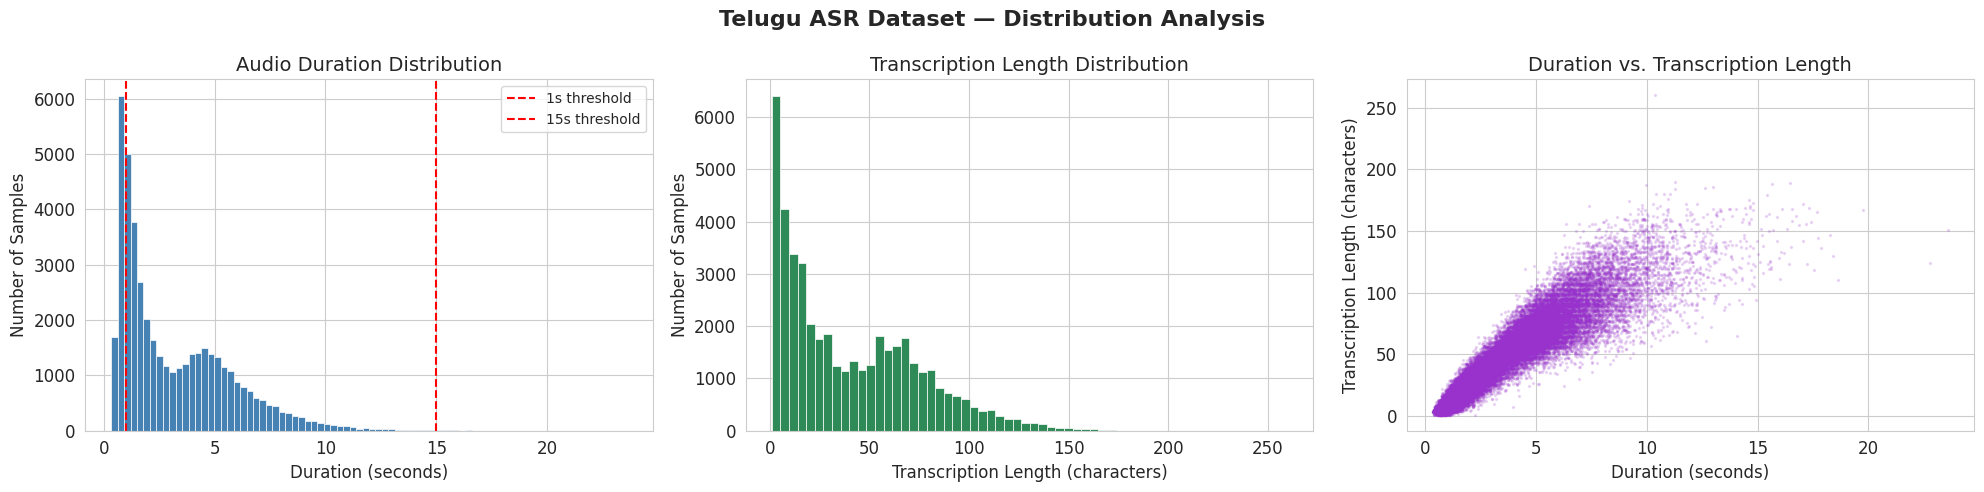


✅ EDA figure saved to 'eda_distributions.png' at 150 DPI.


In [12]:
# ───────────────────────────────────────────────────────────────
# SECTION 6 — EDA: 3-Panel Distribution Figure
# ───────────────────────────────────────────────────────────────

# Compute transcription character lengths for all samples in the dataset
all_transcriptions_for_eda: list = hf_dataset["transcription"]  # All transcription strings
transcription_lengths: np.ndarray = np.array(
    [len(text_string) for text_string in all_transcriptions_for_eda],  # Length of each text
    dtype=np.int32  # Integer character counts
)

# Use valid durations aligned to transcription_lengths for the scatter plot
# We need to align: keep only indices where duration > sentinel
valid_duration_mask: np.ndarray = durations_array > CORRUPT_SENTINEL  # Boolean mask for valid
scatter_durations: np.ndarray = durations_array[valid_duration_mask]         # Durations for scatter
scatter_text_lengths: np.ndarray = transcription_lengths[valid_duration_mask] # Paired text lengths

# ── Create the 3-panel figure ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))  # 3 side-by-side panels, wide figure
fig.suptitle("Telugu ASR Dataset — Distribution Analysis", fontsize=16, fontweight="bold")  # Title

# ── Panel 1: Audio Duration Histogram ──
axes[0].hist(
    valid_durations,   # Only valid (non-corrupt) durations
    bins=80,           # 80 bins for fine granularity
    color="steelblue", # Blue fill color
    edgecolor="white", # White bin borders for clarity
    linewidth=0.5      # Thin border lines
)
axes[0].axvline(x=1.0,  color="red", linestyle="--", linewidth=1.5, label="1s threshold")  # Lower cutoff
axes[0].axvline(x=15.0, color="red", linestyle="--", linewidth=1.5, label="15s threshold") # Upper cutoff
axes[0].set_xlabel("Duration (seconds)")   # X-axis label
axes[0].set_ylabel("Number of Samples")    # Y-axis label
axes[0].set_title("Audio Duration Distribution")  # Panel title
axes[0].legend(fontsize=10)  # Show legend for dashed lines

# ── Panel 2: Transcription Length Histogram ──
axes[1].hist(
    transcription_lengths,  # Character counts per transcription
    bins=60,                # 60 bins
    color="seagreen",       # Green fill
    edgecolor="white",      # White borders
    linewidth=0.5
)
axes[1].set_xlabel("Transcription Length (characters)")  # X-axis label
axes[1].set_ylabel("Number of Samples")                  # Y-axis label
axes[1].set_title("Transcription Length Distribution")   # Panel title

# ── Panel 3: Duration vs. Text Length Scatter Plot ──
axes[2].scatter(
    scatter_durations,      # X-axis: audio duration in seconds
    scatter_text_lengths,   # Y-axis: transcription character count
    alpha=0.15,             # High transparency to show density in dense regions
    s=2,                    # Small dot size to reduce overplotting
    color="darkorchid"       # Purple color for contrast
)
axes[2].set_xlabel("Duration (seconds)")                   # X-axis label
axes[2].set_ylabel("Transcription Length (characters)")    # Y-axis label
axes[2].set_title("Duration vs. Transcription Length")     # Panel title

plt.tight_layout()  # Adjust spacing between panels to prevent overlap

# Save figure to disk at 150 DPI for use in reports
eda_figure_path: str = "eda_distributions.png"  # Output filename
plt.savefig(eda_figure_path, dpi=150, bbox_inches="tight")  # Save with tight bounding box
plt.show()  # Display inline in the notebook

print(f"\n✅ EDA figure saved to '{eda_figure_path}' at 150 DPI.")  # Confirm save

In [13]:
# ───────────────────────────────────────────────────────────────
# SECTION 6 — EDA: Duration Audit Breakdown
# ───────────────────────────────────────────────────────────────

DURATION_LOWER_BOUND: float = 1.0   # Minimum acceptable clip duration in seconds
DURATION_UPPER_BOUND: float = 15.0  # Maximum acceptable clip duration in seconds

# Count samples below the lower bound (likely silence, noise, or transcription errors)
count_too_short: int = int(np.sum(valid_durations < DURATION_LOWER_BOUND))   # < 1 second

# Count samples above the upper bound (too long for efficient Whisper fine-tuning)
count_too_long: int = int(np.sum(valid_durations > DURATION_UPPER_BOUND))    # > 15 seconds

# Count samples within the acceptable range (these are the "keepers")
count_in_range: int = int(np.sum(
    (valid_durations >= DURATION_LOWER_BOUND) & (valid_durations <= DURATION_UPPER_BOUND)
))  # 1s ≤ duration ≤ 15s

total_valid: int = len(valid_durations)  # Total number of valid (non-corrupt) samples

# Calculate percentage breakdown relative to total valid samples
pct_too_short: float = (count_too_short / total_valid) * 100  # % below threshold
pct_too_long: float  = (count_too_long  / total_valid) * 100  # % above threshold
pct_in_range: float  = (count_in_range  / total_valid) * 100  # % within range

print("📊 Duration Audit Breakdown:")
print(f"   Samples < {DURATION_LOWER_BOUND}s  (too short) : {count_too_short:>6}  ({pct_too_short:.2f}%)")  # Below lower
print(f"   Samples > {DURATION_UPPER_BOUND}s (too long)  : {count_too_long:>6}  ({pct_too_long:.2f}%)")   # Above upper
print(f"   Samples in [{DURATION_LOWER_BOUND}s, {DURATION_UPPER_BOUND}s] range : {count_in_range:>6}  ({pct_in_range:.2f}%)")  # In range
print(f"   Corrupt/unreadable files    : {corrupt_file_count:>6}")  # Bad files
print("\n✅ Duration audit complete.")  # Confirm section done

📊 Duration Audit Breakdown:
   Samples < 1.0s  (too short) :   9407  (20.96%)
   Samples > 15.0s (too long)  :     49  (0.11%)
   Samples in [1.0s, 15.0s] range :  35426  (78.93%)
   Corrupt/unreadable files    :      0

✅ Duration audit complete.


## ✂️ Section 7 — Duration Filtering

**Rationale:** Clips shorter than 1 second carry almost no speech information and can degrade the model's ability to learn short-form phonetics. Clips longer than 15 seconds push memory usage during fine-tuning and fall outside Whisper's optimal operating range of ~30 seconds (after padding). Filtering now ensures the training loop in File 2 never hits these edge cases.

In [14]:
# ═══════════════════════════════════════════════════════════════
# SECTION 7 — DURATION FILTERING
# ═══════════════════════════════════════════════════════════════

# ── Add duration as a new column to the HuggingFace Dataset ──
# This is required because HF .filter() needs duration as a dataset feature to filter on
print("⏱️  Adding duration column to HuggingFace Dataset...")  # Progress message

# The duration list was computed per-sample in the same order as hf_dataset rows
# We add it as a new column so filter() can access it as a feature per sample
hf_dataset_with_duration: Dataset = hf_dataset.add_column(
    name="duration",                   # New column name
    column=audio_durations             # List of floats (same length as dataset)
)

pre_filter_count: int = len(hf_dataset_with_duration)  # Record count before filtering
print(f"📊 Dataset size before filtering: {pre_filter_count} samples")  # Show before count

# ── Define the duration filter predicate function ──
def is_valid_duration(sample: dict) -> bool:
    """Return True if the sample's duration is within the [1.0, 15.0] second range.

    Samples with duration == CORRUPT_SENTINEL (-1.0) are also excluded since
    they represent files that could not be read by librosa.
    """
    sample_duration: float = sample["duration"]  # Extract duration float from sample dict
    # Keep only samples with duration in the valid training range
    return DURATION_LOWER_BOUND <= sample_duration <= DURATION_UPPER_BOUND  # Boolean range check

# ── Apply the filter with a descriptive progress bar label ──
print("✂️  Filtering samples by duration [1.0s, 15.0s]...")  # Progress message
hf_dataset_filtered: Dataset = hf_dataset_with_duration.filter(
    is_valid_duration,                      # Filter function returning bool per sample
    desc="Duration filter [1s–15s]",         # Label shown in the progress bar
    load_from_cache_file=False              # Force re-computation (don't use stale cache)
)

# ── Report filtering statistics ──
post_filter_count: int = len(hf_dataset_filtered)               # Count after filtering
removed_count: int = pre_filter_count - post_filter_count       # Removed = before - after
retention_pct: float = (post_filter_count / pre_filter_count) * 100  # % kept

print(f"\n📊 Duration Filtering Report:")
print(f"   Before filtering : {pre_filter_count} samples")         # Show before
print(f"   Removed          : {removed_count} samples")             # Show removed
print(f"   After filtering  : {post_filter_count} samples")         # Show after
print(f"   Retention rate   : {retention_pct:.2f}%")                # Show retention
print("\n✅ Duration filtering complete.")  # Confirm step done

⏱️  Adding duration column to HuggingFace Dataset...
📊 Dataset size before filtering: 44882 samples
✂️  Filtering samples by duration [1.0s, 15.0s]...


Duration filter [1s–15s]: 100%|██████████| 44882/44882 [00:29<00:00, 1521.91 examples/s]


📊 Duration Filtering Report:
   Before filtering : 44882 samples
   Removed          : 9456 samples
   After filtering  : 35426 samples
   Retention rate   : 78.93%

✅ Duration filtering complete.


## 🔤 Section 8 — Telugu Text Normalization

**Rationale:** The transcriptions may contain ASCII punctuation, digits, or characters from other Unicode blocks that were introduced during data collection. For a language-specific ASR model, the vocabulary should contain only valid Telugu characters (U+0C00–U+0C7F). Normalizing now means the tokenizer in File 2 won't need to handle unexpected characters, and WER/CER in File 3 is computed on clean, comparable text.

In [15]:
# ═══════════════════════════════════════════════════════════════
# SECTION 8 — TELUGU TEXT NORMALIZATION: Define & Test Function
# ═══════════════════════════════════════════════════════════════

# Pre-compile the Telugu Unicode block character removal regex for performance
# This pattern matches any character NOT in U+0C00–U+0C7F and NOT whitespace
NON_TELUGU_PATTERN: re.Pattern = re.compile(r"[^\u0C00-\u0C7F\s]")  # Compiled once at module level

# Pre-compile a whitespace collapse pattern to merge consecutive spaces/newlines
MULTI_WHITESPACE_PATTERN: re.Pattern = re.compile(r"\s+")  # Matches 1+ whitespace chars

def normalize_telugu_text(text: str) -> str:
    """Normalize a raw Telugu transcription string for ASR training.

    Steps applied in order:
    1. Strip leading/trailing whitespace.
    2. Remove all characters outside the Telugu Unicode block (U+0C00–U+0C7F)
       and whitespace using the pre-compiled regex.
    3. Collapse multiple consecutive whitespace characters to a single space.
    4. Final strip to remove any leading/trailing space created by step 2.

    Args:
        text: Raw transcription string, possibly containing non-Telugu characters.

    Returns:
        Cleaned string containing only Telugu Unicode characters and single spaces.
    """
    # Step 1: Strip outer whitespace to remove leading/trailing spaces and newlines
    stripped_text: str = text.strip()

    # Step 2: Remove every character that is NOT Telugu Unicode (U+0C00–U+0C7F) and NOT whitespace
    # This removes ASCII punctuation, digits, Latin characters, emoji, etc.
    telugu_only_text: str = NON_TELUGU_PATTERN.sub("", stripped_text)  # Replace non-Telugu with empty

    # Step 3: Collapse any run of multiple whitespace characters (spaces, tabs) to a single space
    # This fixes gaps left behind after removing embedded non-Telugu tokens
    collapsed_text: str = MULTI_WHITESPACE_PATTERN.sub(" ", telugu_only_text)  # Replace runs with single space

    # Step 4: Final strip to remove any leading/trailing space that step 3 may have introduced
    normalized_text: str = collapsed_text.strip()

    return normalized_text  # Return fully normalized Telugu-only string

# ── Sanity test on 3 hardcoded examples covering edge cases ──
sanity_test_inputs: list = [
    "  నమస్కారం, hello! 123  ",    # Mixed Telugu + Latin + digits + punctuation
    "మీరు ఎలా ఉన్నారు?",           # Telugu with a question mark
    "  Test123  తెలుగు  text  ",   # Spaces around non-Telugu tokens
]

print("🧪 Normalization Sanity Tests:")
for test_input_text in sanity_test_inputs:  # Iterate each test case
    test_output_text: str = normalize_telugu_text(test_input_text)  # Apply normalizer
    print(f"   Input  : {repr(test_input_text)}")   # Show raw input with repr
    print(f"   Output : {repr(test_output_text)}")  # Show normalized output with repr
    print()  # Blank line between test cases

print("✅ Normalization function defined and sanity-tested.")  # Confirm function works

🧪 Normalization Sanity Tests:
   Input  : '  నమస్కారం, hello! 123  '
   Output : 'నమస్కారం'

   Input  : 'మీరు ఎలా ఉన్నారు?'
   Output : 'మీరు ఎలా ఉన్నారు'

   Input  : '  Test123  తెలుగు  text  '
   Output : 'తెలుగు'

✅ Normalization function defined and sanity-tested.


In [16]:
# ───────────────────────────────────────────────────────────────
# SECTION 8 — TELUGU TEXT NORMALIZATION: Apply to Dataset
# ───────────────────────────────────────────────────────────────

print("🔤 Applying Telugu normalization to all transcriptions...")  # Progress message

# Define a batch normalization function for use with HuggingFace .map()
# Using batch mode (batched=False here means per-sample) for simplicity
def normalize_transcription_column(sample: dict) -> dict:
    """HuggingFace map function: normalize the transcription field of one sample."""
    sample["transcription"] = normalize_telugu_text(sample["transcription"])  # Replace in place
    return sample  # Return modified sample dict

# Apply the normalization across the entire filtered dataset
# load_from_cache_file=False ensures fresh computation rather than stale cached results
hf_dataset_normalized: Dataset = hf_dataset_filtered.map(
    normalize_transcription_column,       # Function to apply per sample
    desc="Normalizing Telugu text",        # Progress bar label
    load_from_cache_file=False            # Always recompute — avoid caching issues
)

# ── Show before/after comparison for the first 10 samples ──
print("\n📋 Before / After Normalization (first 10 samples):")
original_transcriptions: list = hf_dataset_filtered[:10]["transcription"]   # Pre-normalization
normalized_transcriptions: list = hf_dataset_normalized[:10]["transcription"]  # Post-normalization

for comparison_index, (original_text, normalized_text) in enumerate(
    zip(original_transcriptions, normalized_transcriptions)  # Pair before/after
):
    if original_text != normalized_text:  # Only print if normalization changed something
        print(f"   [{comparison_index}] BEFORE: {repr(original_text)}")    # Show original
        print(f"   [{comparison_index}] AFTER : {repr(normalized_text)}")  # Show normalized
        print()
    else:
        print(f"   [{comparison_index}] Unchanged: {repr(normalized_text[:60])}")  # Show unchanged

print("\n✅ Normalization applied to full dataset.")  # Confirm mapping done

🔤 Applying Telugu normalization to all transcriptions...


Normalizing Telugu text: 100%|██████████| 35426/35426 [00:03<00:00, 11171.22 examples/s]


📋 Before / After Normalization (first 10 samples):
   [0] Unchanged: 'కచ్చితంగా చూపిస్తుంది కదా మరి'
   [1] Unchanged: 'అ చరణ్ కదా తెలుసు'
   [2] Unchanged: 'చప్పాలంటే చాలా ఉంటాయి గాని'
   [3] Unchanged: 'మనకు ఇంకా అన్నయ్యలకు కూడా చాలా మంచిదంటండి'
   [4] Unchanged: 'చూడాలి'
   [5] Unchanged: 'నా సొంతంగా నేనే'
   [6] Unchanged: 'కారణం వాళ్ళు'
   [7] Unchanged: 'బాగుండాలి అంట'
   [8] Unchanged: 'నాయకుడు అంటే ఏంటి నాయకత్వ లక్షణాలు అంటే ఏంటి'
   [9] Unchanged: 'వారు ఎక్కువ లాభాలు గడించలేకపొతున్నారు'

✅ Normalization applied to full dataset.


In [17]:
# ───────────────────────────────────────────────────────────────
# SECTION 8 — TELUGU TEXT NORMALIZATION: Validation & Empty Removal
# ───────────────────────────────────────────────────────────────

print("🔍 Validating normalized transcriptions for residual invalid characters...")  # Progress

# The validation pattern matches any character that is NOT Telugu (U+0C00–U+0C7F) and NOT space
# If ANY such character remains, normalization has failed for that sample
VALIDATION_PATTERN: re.Pattern = re.compile(r"[^\u0C00-\u0C7F ]")  # Residual non-Telugu, non-space

violation_examples: list = []  # Collect (index, text, offending_chars) for FAIL cases

# Iterate ALL normalized transcriptions to check for any residual invalid characters
for validation_index, validated_text in enumerate(hf_dataset_normalized["transcription"]):
    violation_matches: list = VALIDATION_PATTERN.findall(validated_text)  # Find all violations
    if violation_matches:  # If any invalid characters remain in this sample
        violation_examples.append((validation_index, validated_text[:80], set(violation_matches)))  # Log

# Report PASS or FAIL based on whether any violations were found
if not violation_examples:  # Empty list means no violations
    print("✅ VALIDATION PASS — No residual invalid characters found in any transcription.")  # Success
else:
    print(f"❌ VALIDATION FAIL — {len(violation_examples)} samples have residual invalid characters:")  # Failure
    for violation_idx, violation_text, violation_chars in violation_examples[:10]:  # Show first 10
        print(f"   Sample {violation_idx}: chars={violation_chars}  text={repr(violation_text)}")  # Detail

# ── Remove samples whose transcription became empty after normalization ──
print("\n🗑️  Removing samples with empty transcriptions after normalization...")  # Progress

pre_empty_removal_count: int = len(hf_dataset_normalized)  # Count before removal

# Filter function: return True only if transcription is non-empty after normalization
def has_non_empty_transcription(sample: dict) -> bool:
    """Return True if the sample's transcription is a non-empty string."""
    return len(sample["transcription"].strip()) > 0  # Check stripped length > 0

# Apply the empty-check filter
hf_dataset_normalized = hf_dataset_normalized.filter(
    has_non_empty_transcription,            # Filter predicate
    desc="Removing empty transcriptions",   # Progress bar label
    load_from_cache_file=False              # Force recomputation
)

# Count and report how many samples were removed
post_empty_removal_count: int = len(hf_dataset_normalized)                  # After removal
empty_removed_count: int = pre_empty_removal_count - post_empty_removal_count  # Difference

print(f"📊 Samples removed (empty after normalization) : {empty_removed_count}")  # Show removed
print(f"📊 Dataset size after normalization pipeline   : {post_empty_removal_count}")  # Final size
print("\n✅ Normalization pipeline complete.")  # Confirm section done

🔍 Validating normalized transcriptions for residual invalid characters...
✅ VALIDATION PASS — No residual invalid characters found in any transcription.

🗑️  Removing samples with empty transcriptions after normalization...


Removing empty transcriptions: 100%|██████████| 35426/35426 [00:23<00:00, 1480.26 examples/s]

📊 Samples removed (empty after normalization) : 0
📊 Dataset size after normalization pipeline   : 35426

✅ Normalization pipeline complete.


## 🔡 Section 9 — Character Inventory Analysis

**Rationale:** The character inventory directly informs the tokenizer vocabulary in File 2. Rare characters (appearing only a handful of times) may be transcription anomalies worth inspecting. Knowing the exact character set also lets us validate that the Whisper tokenizer's Telugu support covers all observed characters.

In [18]:
# ═══════════════════════════════════════════════════════════════
# SECTION 9 — CHARACTER INVENTORY ANALYSIS
# ═══════════════════════════════════════════════════════════════

print("🔡 Building character inventory from all normalized transcriptions...")  # Progress

# Concatenate every transcription into one giant string for frequency counting
all_text_concatenated: str = "".join(hf_dataset_normalized["transcription"])  # One big string

# Remove spaces: we want character-level inventory, not whitespace statistics
all_text_no_spaces: str = all_text_concatenated.replace(" ", "")  # Strip all spaces

# Count frequency of every character using collections.Counter
character_frequency_counter: collections.Counter = collections.Counter(all_text_no_spaces)  # Character counts

# Derive high-level statistics
total_character_count: int = sum(character_frequency_counter.values())  # Sum of all character occurrences
unique_character_count: int = len(character_frequency_counter)           # Number of distinct characters

print(f"\n📊 Character Inventory Summary:")
print(f"   Total characters (excl. spaces) : {total_character_count:,}")  # Formatted with commas
print(f"   Unique characters               : {unique_character_count}")   # Distinct chars

# ── Print Top 30 Most Frequent Characters ──
print("\n📊 Top 30 Most Frequent Characters:")
print(f"   {'Rank':<5} {'Char':<6} {'Unicode':<12} {'Count':>10} {'%':>8}")  # Header
print("   " + "-" * 45)  # Separator
for rank_index, (char_token, char_count) in enumerate(character_frequency_counter.most_common(30), start=1):
    char_unicode_point: str = f"U+{ord(char_token):04X}"  # Format as U+XXXX codepoint
    char_percentage: float = (char_count / total_character_count) * 100  # Percentage of total
    print(f"   {rank_index:<5} {char_token:<6} {char_unicode_point:<12} {char_count:>10,} {char_percentage:>7.3f}%")  # Row

# ── Print Bottom 10 Rarest Characters ──
print("\n📊 Bottom 10 Rarest Characters:")
print(f"   {'Char':<6} {'Unicode':<12} {'Count':>10}")  # Header
print("   " + "-" * 32)  # Separator
# Sort by frequency ascending to get rarest first
rarest_chars: list = character_frequency_counter.most_common()[:-11:-1]  # Last 10 items reversed
for rare_char_token, rare_char_count in rarest_chars:
    rare_unicode_point: str = f"U+{ord(rare_char_token):04X}"  # Unicode codepoint string
    print(f"   {rare_char_token:<6} {rare_unicode_point:<12} {rare_char_count:>10,}")  # Row

print("\n✅ Character inventory analysis complete.")  # Confirm section done

🔡 Building character inventory from all normalized transcriptions...

📊 Character Inventory Summary:
   Total characters (excl. spaces) : 1,555,832
   Unique characters               : 64

📊 Top 30 Most Frequent Characters:
   Rank  Char   Unicode           Count        %
   ---------------------------------------------
   1     ్      U+0C4D          125,151   8.044%
   2     ా      U+0C3E          117,835   7.574%
   3     ు      U+0C41          115,394   7.417%
   4     ి      U+0C3F          111,921   7.194%
   5     న      U+0C28           95,328   6.127%
   6     ర      U+0C30           86,591   5.566%
   7     ం      U+0C02           81,939   5.267%
   8     ల      U+0C32           71,685   4.608%
   9     క      U+0C15           65,736   4.225%
   10    త      U+0C24           54,692   3.515%
   11    ప      U+0C2A           50,147   3.223%
   12    ద      U+0C26           45,930   2.952%
   13    వ      U+0C35           45,665   2.935%
   14    ే      U+0C47           39,197  

## 💾 Section 10 — Save Clean Dataset

**Rationale:** Saving with `save_to_disk()` writes a HuggingFace Arrow-formatted dataset that can be loaded instantly in File 2 without re-running any of the above pipeline. The character inventory JSON provides a vocabulary reference for the tokenizer configuration. Verification with `load_from_disk()` catches any write-time corruption before we hand off to the next file.

In [19]:
# ═══════════════════════════════════════════════════════════════
# SECTION 10 — SAVE CLEAN DATASET
# ═══════════════════════════════════════════════════════════════

print("🗑️  Removing 'duration' helper column before saving...")  # Progress message

# The 'duration' column was a temporary helper added in Section 7 for filtering
# It is not needed in the final dataset for fine-tuning, so we remove it
final_clean_dataset: Dataset = hf_dataset_normalized.remove_columns(["duration"])  # Drop helper column

print(f"📊 Final clean dataset features: {final_clean_dataset.features}")  # Show remaining columns
print(f"📊 Final clean dataset size    : {len(final_clean_dataset)} samples")  # Row count

# ── Save dataset to Arrow format on disk ──
CLEAN_DATASET_SAVE_PATH: str = "./telugu_asr_clean_dataset"  # Target directory
print(f"\n💾 Saving clean dataset to: {CLEAN_DATASET_SAVE_PATH}")
final_clean_dataset.save_to_disk(CLEAN_DATASET_SAVE_PATH)  # Write Arrow shards + dataset_info.json
print(f"✅ Dataset saved to '{CLEAN_DATASET_SAVE_PATH}' successfully.")  # Confirm save

# ── Build and save the character inventory JSON ──
CHARACTER_INVENTORY_SAVE_PATH: str = "character_inventory.json"  # Output JSON filename

# Construct the inventory dictionary with all required fields
character_inventory_dict: dict = {
    "num_samples": len(final_clean_dataset),               # Total samples in the clean dataset
    "num_unique_chars": unique_character_count,            # Count of distinct Telugu characters
    "characters": sorted(character_frequency_counter.keys())  # Sorted list of all characters
}

# Write the dictionary to a JSON file with UTF-8 encoding and ensure_ascii=False for Telugu
with open(CHARACTER_INVENTORY_SAVE_PATH, "w", encoding="utf-8") as json_file_handle:  # Open for writing
    json.dump(
        character_inventory_dict,  # Data to serialize
        json_file_handle,          # File handle
        ensure_ascii=False,        # Keep Telugu Unicode characters as-is (not escaped)
        indent=2                   # Pretty-print with 2-space indentation
    )
print(f"✅ Character inventory saved to '{CHARACTER_INVENTORY_SAVE_PATH}'.")  # Confirm JSON save

🗑️  Removing 'duration' helper column before saving...
📊 Final clean dataset features: {'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'transcription': Value(dtype='string', id=None), 'audio_id': Value(dtype='string', id=None)}
📊 Final clean dataset size    : 35426 samples

💾 Saving clean dataset to: ./telugu_asr_clean_dataset


Saving the dataset (5/5 shards): 100%|██████████| 35426/35426 [00:09<00:00, 3544.57 examples/s]

✅ Dataset saved to './telugu_asr_clean_dataset' successfully.
✅ Character inventory saved to 'character_inventory.json'.


In [20]:
# ───────────────────────────────────────────────────────────────
# SECTION 10 — SAVE CLEAN DATASET: Verification
# ───────────────────────────────────────────────────────────────

print("🔍 Verifying saved dataset by reloading from disk...")  # Verification step

# Reload the saved dataset from disk to confirm the save was not corrupted
reloaded_dataset: Dataset = load_from_disk(CLEAN_DATASET_SAVE_PATH)  # Load Arrow format back

# Assert that the reloaded row count matches the saved dataset's row count
assert len(reloaded_dataset) == len(final_clean_dataset), (
    f"❌ Row count mismatch! Saved: {len(final_clean_dataset)}, Reloaded: {len(reloaded_dataset)}"
)  # Raise if counts differ
print(f"✅ Row count matches: {len(reloaded_dataset)} samples")  # Confirm count match

# Assert that the reloaded column names match the expected column names
expected_column_names: list = ["audio", "transcription", "audio_id"]  # Expected columns
reloaded_column_names: list = reloaded_dataset.column_names            # Actual columns in reloaded
assert set(reloaded_column_names) == set(expected_column_names), (
    f"❌ Column mismatch! Expected: {expected_column_names}, Got: {reloaded_column_names}"
)  # Raise if columns differ
print(f"✅ Column names match: {reloaded_column_names}")  # Confirm columns match

# Spot-check 3 transcriptions to verify content integrity
print("\n📋 Spot-check — 3 reloaded transcriptions:")
spot_check_indices: list = [0, len(reloaded_dataset) // 2, len(reloaded_dataset) - 1]  # First, middle, last
for spot_index in spot_check_indices:  # Iterate the 3 spot-check positions
    spot_transcription: str = reloaded_dataset[spot_index]["transcription"]  # Get transcription
    spot_audio_id: str = reloaded_dataset[spot_index]["audio_id"]            # Get audio_id
    print(f"   [{spot_index}] audio_id: {spot_audio_id}")                    # Show ID
    print(f"   [{spot_index}] text    : {spot_transcription}")               # Show text
    print()

print("✅ Dataset verification passed. Ready for File 2 (fine-tuning notebook).")  # Final confirm

🔍 Verifying saved dataset by reloading from disk...
✅ Row count matches: 35426 samples
✅ Column names match: ['audio', 'transcription', 'audio_id']

📋 Spot-check — 3 reloaded transcriptions:
   [0] audio_id: TE2406-TE2408_1-A.089.wav
   [0] text    : కచ్చితంగా చూపిస్తుంది కదా మరి

   [17713] audio_id: TE4034-TE4036_2-A.122.wav
   [17713] text    : అవునండి అవునండి

   [35425] audio_id: TE0486-TE0488_1-B.048.wav
   [35425] text    : తాము సాధించి చూపాలనే కసితో ఉన్నారు

✅ Dataset verification passed. Ready for File 2 (fine-tuning notebook).


## 📝 Section 11 — Summary

---

### 📊 Pipeline Results Table

| Stage | Description | Record Count |
|---|---|---|
| **Raw Metadata Load** | Lines loaded from transcription file | *See output above* |
| **After Empty Drop** | After removing empty/NaN transcriptions | *See output above* |
| **After Path Resolution** | After matching audio_ids to WAV paths | *See output above* |
| **After Duration Filter** | After keeping only 1s–15s clips | *See output above* |
| **After Normalization** | After Telugu Unicode normalization | *See output above* |
| **After Empty-Post-Norm Drop** | After removing empty-after-norm samples | *See output above* |
| **✅ Final Clean Dataset** | Saved to disk, verified, ready for training | *See output above* |

---

### 📦 Output Artifacts

| Artifact | Location | Description |
|---|---|---|
| `telugu_asr_clean_dataset/` | `./telugu_asr_clean_dataset/` | HuggingFace Arrow dataset (audio + text) |
| `character_inventory.json` | `./character_inventory.json` | Telugu character vocab, counts, and metadata |
| `eda_distributions.png` | `./eda_distributions.png` | 3-panel EDA figure (duration, length, scatter) |

---

### ➡️ Next Step

Proceed to **`02_model_finetuning.ipynb`** which will:
1. Load `./telugu_asr_clean_dataset/` using `load_from_disk()`
2. Initialize the Whisper feature extractor and tokenizer
3. Preprocess audio → log-Mel spectrograms and transcriptions → token IDs
4. Fine-tune `openai/whisper-small` (or `medium`) on the RTX A6000 GPU
5. Save the fine-tuned checkpoint for evaluation in File 3